## Molmo2 Fine-tune Notebook

* this notebook is based on the blogpost by Philschmid, where he wlaks through fine tuning VLMs. We will tweak it to use Molmo2

* I was actually impressed at how good Molmo2 was out of the box in these images. Their previous verson had a very difficult time even telling what was in the image, but this one is much much sharper. Still, as a learning experience (and this is probably something that would actually need to be done to use this model for real scientific research), let's fine tune to get exactly the answers we want to help ground pose, location, and better description of the images. So for example:

```
┌──────────────────────────┬────────────────────────────┬────────────────────────────────────────────────────────────────────┐   
│         Question         │       Generic answer       │                       Domain-precise answer                        │
├──────────────────────────┼────────────────────────────┼────────────────────────────────────────────────────────────────────┤   
│ "How many mice and       │ "Two mice, one top one     │ "2 mice. Mouse A at (640, 320), Mouse B at (400, 800)"             │
│ where?"                  │ bottom"                    │                                                                    │
├──────────────────────────┼────────────────────────────┼────────────────────────────────────────────────────────────────────┤   
│ "Is this mouse           │ "The mouse appears to be   │ "Yes — forepaws are elevated near the snout, head is flexed        │   
│ grooming?"               │ cleaning itself"           │ ventrally, consistent with face grooming behavior"                 │   
├──────────────────────────┼────────────────────────────┼────────────────────────────────────────────────────────────────────┤   
│ "What body parts are     │ "Part of the mouse is      │ "Left ear and left hindpaw of mouse closest to the left are        │
│ occluded?"               │ hidden"                    │ occluded"                                                          │   
├──────────────────────────┼────────────────────────────┼────────────────────────────────────────────────────────────────────┤
│ "Estimate the            │ Can't do this              │ "Nose-to-nose distance is approximately 150px (~4cm at this        │   
│ inter-mouse distance"    │                            │ scale)"                                                            │   
└──────────────────────────┴────────────────────────────┴────────────────────────────────────────────────────────────────────┘

In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [1]:
 %pip install "transformers==4.57.1"

  Using cached transformers-4.57.1-py3-none-any.whl.metadata (43 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
Using cached transformers-4.57.1-py3-none-any.whl (12.0 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.8.0
    Uninstalling huggingface_hub-1.8.0:
      Successfully uninstalled huggingface_hub-1.8.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.4.0
    Uninstalling transformers-5.4.0:
      Successfully uninstalled transformers-5.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


In [2]:
import transformers
print(transformers.__version__)

4.57.1


In [1]:
# Cell 1a: Install dependencies
%pip install --upgrade \
  torch \
  torchvision \
  "transformers>=4.57.1" \
  "datasets>=3.0.1" \
  "accelerate>=0.34.2" \
  "bitsandbytes>=0.44.0" \
  "trl>=0.15.0" \
  "peft>=0.13.0" \
  pillow tensorboard

# Fix CUDA library paths (Colab-specific)
!ln -sf /usr/local/lib/python3.12/dist-packages/nvidia/cu13/lib/libnvrtc-builtins.so.13.0 /usr/lib/libnvrtc-builtins.so.13.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 81.0 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 0.36.2
    Uninstalling huggingface_hub-0.36.2:
      Successfully uninstalled huggingface_hub-0.36.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.1
    Uninstalling transformers-4.57.1:
      Successfully uninstalled transformers-4.57.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


* Now we load our VQA dataset from huggingface:

In [2]:
from huggingface_hub import login, snapshot_download
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'), add_to_git_credential=True)

snapshot_download("jpoberhauser/sleap-mice-vqa", repo_type="dataset", local_dir="data")

# Unzip frames if they were uploaded as a zip
import os
if os.path.exists("data/frames.zip") and not os.path.exists("data/frames/frame_0000.png"):
    !unzip -q data/frames.zip -d data/
    print("Frames unzipped.")
else:
    print("Frames already available.")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Frames already available.


In [7]:
# Unzip frames
# !unzip /content/data/frames.zip -d /content/data/

In [3]:
!ls /content/data/

all.json  frames  frames.zip  train.json  val.json


Train: 11011 QA pairs
Val:   1976 QA pairs
data/frames/frame_0854.png
data/frames/frame_0797.png
data/frames/frame_0839.png
data/frames/frame_0226.png
data/frames/frame_0744.png
data/frames/frame_0557.png


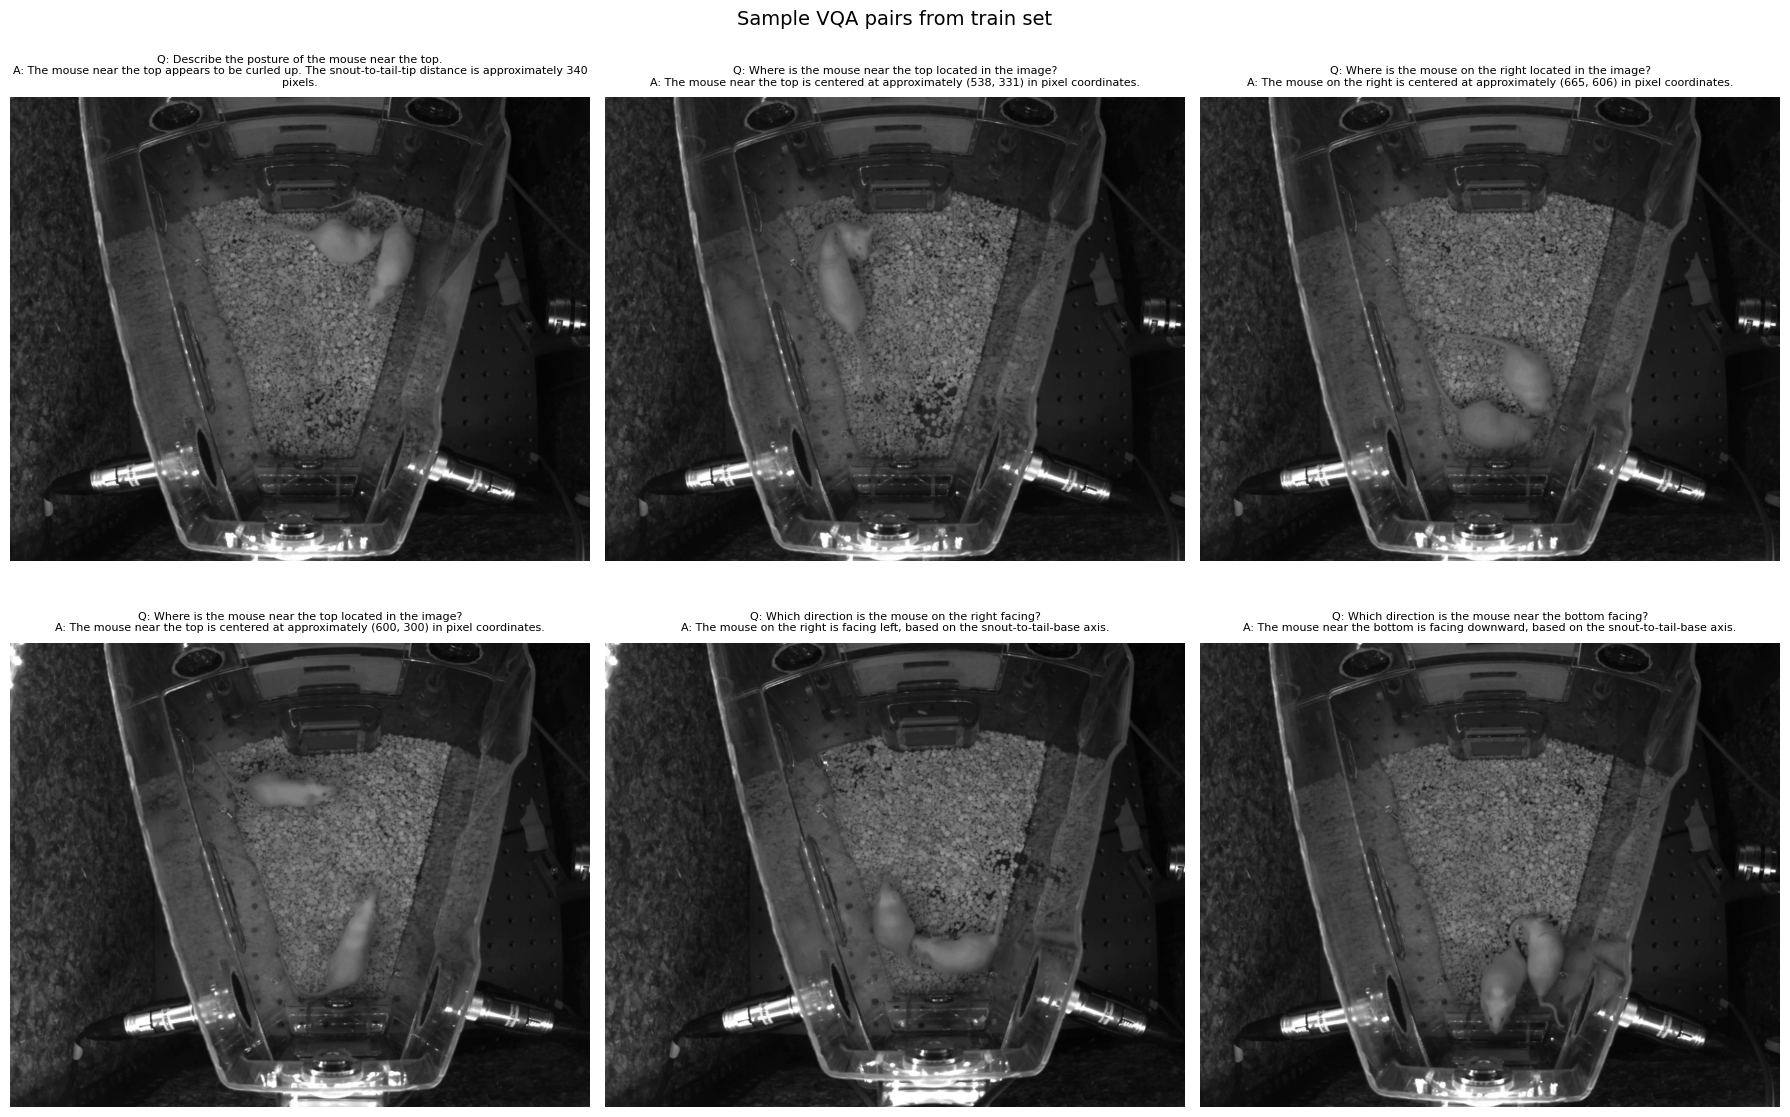

In [4]:
import json
import matplotlib.pyplot as plt
from PIL import Image
import random

# Load from saved JSON
with open("/content/data/train.json") as f:
    train_data = json.load(f)

with open("/content/data/val.json") as f:
    val_data = json.load(f)

print(f"Train: {len(train_data)} QA pairs")
print(f"Val:   {len(val_data)} QA pairs")

# Show random samples with their images
random.seed(1023)
samples = random.sample(train_data, 6)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, sample in zip(axes.flat, samples):
    old_dir = sample["image"]
    new_dir = f"/content/{old_dir}"
    img = Image.open(new_dir)
    print(sample["image"])
    ax.imshow(img, cmap="gray")
    # Wrap the Q/A text for display
    q = sample["question"]
    a = sample["answer"]
    ax.set_title(f"Q: {q}\nA: {a}", fontsize=8, wrap=True, pad=10)
    ax.axis("off")

plt.suptitle("Sample VQA pairs from train set", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
#!ln -sf /usr/local/lib/python3.12/dist-packages/nvidia/cu13/lib/libnvrtc-builtins.so.13.0 /usr/lib/libnvrtc-builtins.so.13.0

In [6]:
# import os
# os.environ['LD_LIBRARY_PATH'] = '/usr/local/lib/python3.12/dist-packages/nvidia/nvjitlink/lib:'
# os.environ.get('LD_LIBRARY_PATH', '')

In [3]:
import torch
from transformers import AutoModelForImageTextToText, AutoProcessor

model_id = "allenai/Molmo2-4B"

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.float32,
    device_map="auto",
    trust_remote_code=True,
)
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
print(f"Model loaded. dtype: {model.dtype}")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

processor_config.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.5M [00:00<?, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Model loaded. dtype: torch.float32


In [4]:
from PIL import Image

img = Image.open("data/frames/frame_0000.png").convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            dict(type="image", image=img),
            dict(type="text", text="How many mice are in this image? Describe their positions and postures."),
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True,
)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.inference_mode():
    output = model.generate(**inputs, max_new_tokens=256)

generated_tokens = output[0, inputs["input_ids"].size(1):]
print("Base model response:")
print(processor.tokenizer.decode(generated_tokens, skip_special_tokens=True))

Base model response:
There are two mice visible in this image. They are positioned in the center of the container, facing each other. The mouse on the left is facing left, while the mouse on the right is facing right. Both mice appear to be in a relaxed posture, with their tails visible. The container they're in seems to be a clear plastic enclosure with a gravelly bottom, likely a pet habitat or research setup.


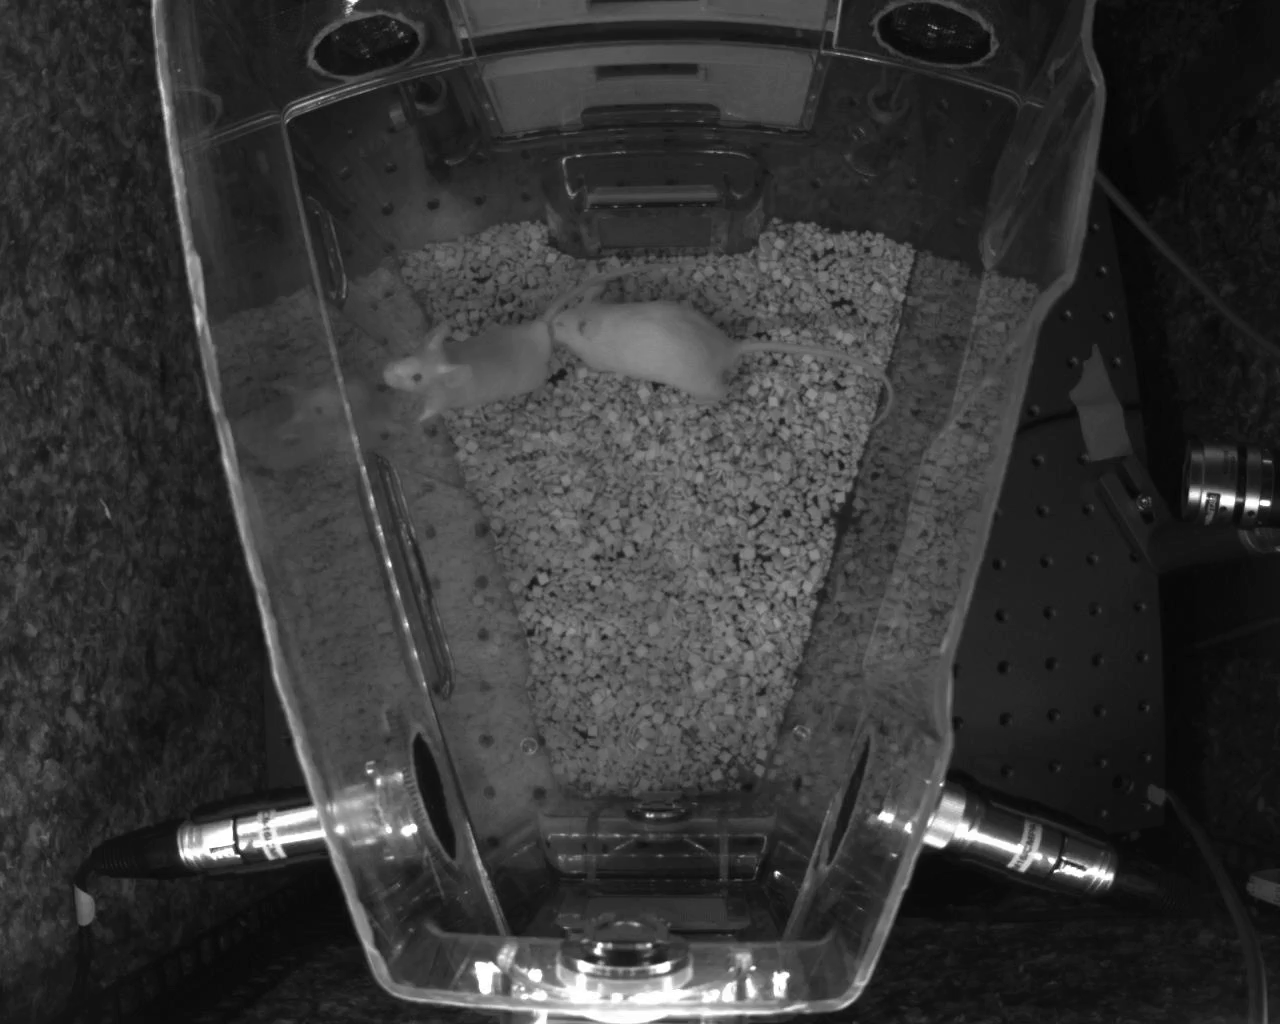

In [5]:
img

As you can see, the model is good at general things, but it says the mice are facing each other (incorrectly), when they are not.
It also says mouse on the left is facing left (correctly) but incorrectly saus the mouse on the right is facing right.

## Lets fine-tune with LORA adapters

### Step 1: Attach LoRA adapters

LoRA (Low-Rank Adaptation) freezes the base model and injects small trainable matrices into the attention layers. Instead of updating all ~4B parameters, we only train ~0.5-1% of them.

Key choices:
- `r=16` — rank of the low-rank matrices (higher = more capacity but more params
- `lora_alpha=32` — scaling factor (rule of thumb: 2x the rank)
- We target the query, key, value, and output projection layers in the LLM


Ok, how do we find the target modules that we actually want? LEts print them out to understand what the model has and how they are named:

In [6]:

import torch
from transformers import AutoModelForImageTextToText, AutoProcessor

model_id = "allenai/Molmo2-4B"

model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    torch_dtype=torch.float32,
    device_map="auto",
    trust_remote_code=True,
)
processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)
print(f"Model loaded. dtype: {model.dtype}")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Model loaded. dtype: torch.float32


In [14]:
# for name, module in model.named_modules():
#     if "attn" in name.lower() or "proj" in name.lower():
#         print(name)

* so it looks like we want to add adapters to `attn_proj`, `attn_out`, and `ff_proj`.

* why?

* `attn_proj` : this layer is a projection of the three q,k,v matrices. this is where the multi-modal model is actually deciding what to attend to.

* `attn_out` : This is the layer where we add the `W_o` projection. This comes right after we finish the multi-head attention. In our PaliGemma implementation it looks like:
```python
#self.out_proj applies the final linear projection W_O on the concatenated result, matching the standard formula: Output =   
        #Concat(head_1, ..., head_h) · W_O.
        attn_output = self.out_proj(attn_output)# we need this to mix between heads.
# where the out_proj was defined as:
self.out_proj = nn.Linear(self.embed_dim, self.embed_dim) # W_o matrix


```
* lastly, `ff_proj` : this is the feedForward layer in the mutli-head attention code. this is where the model will do per-token transformations right after attention.

#### LoRA
* for LoRa, its kind of standard practice to start with attention layers. this comes right from the LoRa paper where they show that attention projections are the best parameter-efficient targets to add adapters to.

* if we want to be more conservative, we can just add adapters to `attn_proj` and see how far that gets us for our use case.

* if we add all three layers, we get a print out saying trainable parameters are ~21M out of the 4.8B parameters in the full model, so we will train about 4.4% of the parameters

In [7]:
from peft import LoraConfig, get_peft_model

# Freeze the vision encoder — we only want to fine-tune the language model
for param in model.model.vision_backbone.parameters():
    param.requires_grad = False

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.0,
    target_modules=["att_proj", "attn_out", "ff_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)

# Forward hook to enable gradients through frozen layers.
# We need to find the correct path to the first transformer block.
def make_inputs_require_grad(module, input, output):
    if isinstance(output, tuple):
        output[0].requires_grad_(True)
    else:
        output.requires_grad_(True)

# Find and hook the first transformer block (path varies by how model is wrapped)
hooked = False
for name, module in model.named_modules():
    if name.endswith("blocks.0") and "vision" not in name:
        module.register_forward_hook(make_inputs_require_grad)
        print(f"Gradient hook attached to: {name}")
        hooked = True
        break

if not hooked:
    print("WARNING: Could not find transformer blocks. Listing candidates:")
    for name, module in model.named_modules():
        if "blocks.0" in name:
            print(f"  {name}")

model.print_trainable_parameters()

ERROR:bitsandbytes.cextension:bitsandbytes library load error: libnvJitLink.so.13: cannot open shared object file: No such file or directory
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/bitsandbytes/cextension.py", line 320, in <module>
    lib = get_native_library()
          ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/bitsandbytes/cextension.py", line 298, in get_native_library
    dll = ct.cdll.LoadLibrary(str(binary_path))
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 460, in LoadLibrary
    return self._dlltype(name)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: libnvJitLink.so.13: cannot open shared object file: No such file or directory


Gradient hook attached to: base_model.model.model.transformer.blocks.0
trainable params: 21,528,576 || all params: 4,872,397,776 || trainable%: 0.4418


In [9]:
import json
from datasets import Dataset

# Load VQA data
with open("data/train.json") as f:
    train_raw = json.load(f)
with open("data/val.json") as f:
    val_raw = json.load(f)

def format_to_chat(examples):
    """Convert VQA JSON into chat message format. Stores image paths (lazy loading)."""
    formatted = []
    for ex in examples:
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": ex["image"]},
                    {"type": "text", "text": ex["question"]},
                ],
            },
            {
                "role": "assistant",
                "content": [
                    {"type": "text", "text": ex["answer"]},
                ],
            },
        ]
        formatted.append({"messages": messages})
    return formatted

train_formatted = format_to_chat(train_raw)
val_formatted = format_to_chat(val_raw)

train_dataset = Dataset.from_list(train_formatted)
val_dataset = Dataset.from_list(val_formatted)

print(f"Train: {len(train_dataset)} examples")
print(f"Val:   {len(val_dataset)} examples")

Train: 11011 examples
Val:   1976 examples


In [10]:
train_dataset = Dataset.from_list(train_formatted)
val_dataset = Dataset.from_list(val_formatted)

print(train_dataset)
print(val_dataset)

Dataset({
    features: ['messages'],
    num_rows: 11011
})
Dataset({
    features: ['messages'],
    num_rows: 1976
})


In [16]:
  from PIL import Image

  def collate_fn(examples):
      """Custom collator — processes one example at a time.
      Molmo2's multi-crop image handling requires batch_size=1."""

      ex = examples[0]  # single example per batch

      # Build messages with lazily loaded images
      messages = []
      for msg in ex["messages"]:
          new_content = []
          for content in msg["content"]:
              if content["type"] == "image":
                  img = Image.open(content["image"]).convert("RGB")
                  new_content.append({"type": "image", "image": img})
              else:
                  new_content.append(content)
          messages.append({"role": msg["role"], "content": new_content})

      # Process through apply_chat_template
      batch = processor.apply_chat_template(
          messages,
          add_generation_prompt=False,
          tokenize=True,
          return_tensors="pt",
          return_dict=True,
      )

      # Create labels — mask tokens the model shouldn't predict:
      # 1. Padding tokens
      # 2. Image/special tokens that are >= vocab_size (handled internally, not by the LM head)
      labels = batch["input_ids"].clone()
      vocab_size = processor.tokenizer.vocab_size
      if processor.tokenizer.pad_token_id is not None:
          labels[labels == processor.tokenizer.pad_token_id] = -100
      labels[labels >= vocab_size] = -100  # mask image patch tokens and other special tokens
      batch["labels"] = labels

      return batch

  # Quick test
  test_batch = collate_fn([train_formatted[0]])
  print(f"Input IDs shape: {test_batch['input_ids'].shape}")
  print(f"Keys: {list(test_batch.keys())}")

  # Verify no out-of-range labels
  labels = test_batch["labels"]
  valid_labels = labels[labels != -100]
  vocab_size = processor.tokenizer.vocab_size
  print(f"Valid label range: {valid_labels.min()} to {valid_labels.max()}")
  print(f"Any labels >= vocab_size? {(valid_labels >= vocab_size).any()}")
  print(f"Tokens masked as -100: {(labels == -100).sum().item()} out of {labels.numel()}")

Input IDs shape: torch.Size([1, 1011])
Keys: ['input_ids', 'attention_mask', 'token_type_ids', 'pixel_values', 'image_token_pooling', 'image_grids', 'image_num_crops', 'labels']
Valid label range: 13 to 77091
Any labels >= vocab_size? False
Tokens masked as -100: 986 out of 1011


## Note on the clamping above

* why do we need to check if there are labels greater than the vocab size?
* I think what was happening, and i dont know if this is best practice (?) is that cross entropy loss was receiving the image_tokens along the predicted text_tokens. That is obviously not what we want, we just want the model to be graded on the text_tokens it produces, not the image tokens!
* in pytorch, cross_entropy has an ignore index, which is -100. So if we take any image tokens that exceeded the vocab_size, and set it to -100, then we only grade the model on the text_tokens.
* I believe the Molmo2 fine-tuning handles this internally, but the `labels = input_ids.clone()` in huggingface did not handle that properly?
* There might be a better best-practice here, but lets see if this works?

In [ ]:
# What are ALL the image-related token IDs?
print(f"image_patch_id: {model.config.image_patch_id}")

# Check all config attributes for image token IDs
for attr in dir(model.config):
    if "image" in attr.lower() or "patch" in attr.lower():
        val = getattr(model.config, attr)
        if isinstance(val, int):
            print(f"{attr}: {val} (>= vocab? {val >= 151643})")

In [17]:
test_batch = {k: v.to(model.device) if hasattr(v, 'to') else v for k, v in test_batch.items()}
output = model(**test_batch)
print(f"Forward OK! Loss: {output.loss.item():.4f}")

output.loss.backward()
print("Backward OK!")

# Check gradients reached LoRA params
grads_ok = sum(1 for n, p in model.named_parameters() if p.requires_grad and p.grad is not None)
grads_none = sum(1 for n, p in model.named_parameters() if p.requires_grad and p.grad is None)
print(f"Params with gradients: {grads_ok}")
print(f"Params with NO gradients: {grads_none}")

model.zero_grad()

if grads_none == 0:
    print("\nAll good — ready to train!")

Forward OK! Loss: 4.1107
Backward OK!
Params with gradients: 216
Params with NO gradients: 0

All good — ready to train!


In [18]:
test_batch = collate_fn([train_formatted[0]])

vocab_size = processor.tokenizer.vocab_size
print(f"Vocab size: {vocab_size}")

labels = test_batch["labels"]
valid_labels = labels[labels != -100]
print(f"Label range: {valid_labels.min()} to {valid_labels.max()}")
print(f"Any labels >= vocab_size? {(valid_labels >= vocab_size).any()}")

input_ids = test_batch["input_ids"]
print(f"Input ID range: {input_ids.min()} to {input_ids.max()}")
print(f"Any input_ids >= vocab_size? {(input_ids >= vocab_size).any()}")

Vocab size: 151643
Label range: 13 to 77091
Any labels >= vocab_size? False
Input ID range: 13 to 151940
Any input_ids >= vocab_size? True


In [19]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./molmo2-mice-lora",
    num_train_epochs=3,
    per_device_train_batch_size=1,    # must be 1 for Molmo2's multi-crop images
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,    # effective batch size = 8
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=3,
    fp16=False,                       # no mixed precision — everything is fp32
    bf16=False,
    gradient_checkpointing=False,     # disabled — 98GB VRAM is plenty
    dataloader_pin_memory=False,
    remove_unused_columns=False,
    report_to="tensorboard",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=collate_fn,
)

print(f"Training on {len(train_dataset)} examples")
print(f"Evaluating on {len(val_dataset)} examples")
print(f"Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Steps per epoch: ~{len(train_dataset) // training_args.gradient_accumulation_steps}")

The model is already on multiple devices. Skipping the move to device specified in `args`.


Training on 11011 examples
Evaluating on 1976 examples
Effective batch size: 8
Steps per epoch: ~1376


In [20]:
 # 1. Verify LoRA params are trainable and in the right dtype
trainable = [(n, p.dtype, p.shape) for n, p in model.named_parameters() if p.requires_grad]
print(f"Trainable params: {len(trainable)}")
for name, dtype, shape in trainable[:5]:
    print(f"  {name}: {dtype}, {shape}")

Trainable params: 216
  base_model.model.model.transformer.blocks.0.self_attn.att_proj.lora_A.default.weight: torch.float32, torch.Size([16, 2560])
  base_model.model.model.transformer.blocks.0.self_attn.att_proj.lora_B.default.weight: torch.float32, torch.Size([6144, 16])
  base_model.model.model.transformer.blocks.0.self_attn.attn_out.lora_A.default.weight: torch.float32, torch.Size([16, 4096])
  base_model.model.model.transformer.blocks.0.self_attn.attn_out.lora_B.default.weight: torch.float32, torch.Size([2560, 16])
  base_model.model.model.transformer.blocks.0.mlp.ff_proj.lora_A.default.weight: torch.float32, torch.Size([16, 2560])


In [21]:
 # 2. Verify gradient hook is working — do a test forward+backward pass
test_batch = collate_fn([train_formatted[0]])
test_batch = {k: v.to(model.device) if hasattr(v, 'to') else v for k, v in test_batch.items()}

# Print shapes and dtypes of all inputs
for k, v in test_batch.items():
    if hasattr(v, 'shape'):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}, device={v.device}")
    else:
        print(f"  {k}: {type(v)}")

# Try forward only first
output = model(**test_batch)
print(f"\nForward pass OK! Loss: {output.loss.item():.4f}")

  input_ids: shape=torch.Size([1, 1011]), dtype=torch.int64, device=cuda:0
  attention_mask: shape=torch.Size([1, 1011]), dtype=torch.int64, device=cuda:0
  token_type_ids: shape=torch.Size([1, 1011]), dtype=torch.bool, device=cuda:0
  pixel_values: shape=torch.Size([7, 729, 588]), dtype=torch.float32, device=cuda:0
  image_token_pooling: shape=torch.Size([955, 4]), dtype=torch.int64, device=cuda:0
  image_grids: shape=torch.Size([1, 4]), dtype=torch.int64, device=cuda:0
  image_num_crops: shape=torch.Size([1]), dtype=torch.int64, device=cuda:0
  labels: shape=torch.Size([1, 1011]), dtype=torch.int64, device=cuda:0

Forward pass OK! Loss: 4.1107


In [22]:
trainer.train()# we are training with fp12 so its sloooow

Step,Training Loss,Validation Loss
200,0.214400,0.189229
400,0.165100,0.174236
600,0.178900,0.166137
800,0.173200,0.163261
1000,0.157400,0.160916
1200,0.161900,0.157965
1400,0.148600,0.153788
1600,0.161000,0.154005
1800,0.132300,0.155237
2000,0.165700,0.151982


KeyboardInterrupt: 

In [23]:
# Save the LoRA adapter
model.save_pretrained("./molmo2-mice-lora/final_adapter")

In [26]:
# model.push_to_hub("jpoberhauser/molmo2-4b-mice-lora")
# processor.push_to_hub("jpoberhauser/molmo2-4b-mice-lora")

In [25]:
# Test on a validation image — compare to ground truth
import random

random.seed(99)
test_sample = random.choice(val_raw)
test_img = Image.open(test_sample["image"]).convert("RGB")

print(f"Question:     {test_sample['question']}")
print(f"Ground truth: {test_sample['answer']}")
print()

messages = [
    {
        "role": "user",
        "content": [
            dict(type="image", image=test_img),
            dict(type="text", text=test_sample["question"]),
        ],
    }
]

inputs = processor.apply_chat_template(
    messages,
    tokenize=True,
    add_generation_prompt=True,
    return_tensors="pt",
    return_dict=True,
)
inputs = {k: v.to(model.device) for k, v in inputs.items()}

with torch.inference_mode():
    output = model.generate(**inputs, max_new_tokens=256)

generated_tokens = output[0, inputs["input_ids"].size(1):]
prediction = processor.tokenizer.decode(generated_tokens, skip_special_tokens=True)
print(f"Fine-tuned model: {prediction}")

Question:     Where is the mouse near the top located in the image?
Ground truth: The mouse near the top is centered at approximately (588, 312) in pixel coordinates.

Fine-tuned model: The mouse near the top is centered at approximately (615, 305) in pixel coordinates. This mouse is near the top of the image, close to the top edge.


And look at the results! so much more detail and grounding extracted for our use case!

- **Question**:     Where is the mouse near the top located in the image?

- **Ground truth**: The mouse near the top is centered at approximately (588, 312) in pixel coordinates.

- **Fine-tuned model**: The mouse near the top is centered at approximately (615, 305) in pixel coordinates. This mouse is near the top of the image, close to the top edge.